In [2]:
import zipfile
import os

# Extracting the zip file if it hasn't been done yet
if not os.path.exists('train-images.idx3-ubyte'):
    with zipfile.ZipFile('handwritten.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Files extracted successfully.")

Files extracted successfully.


Loading data...
Training started...
Iteration   0 | Accuracy: 0.0615
Iteration  50 | Accuracy: 0.4906
Iteration 100 | Accuracy: 0.8074
Iteration 150 | Accuracy: 0.8617
Iteration 200 | Accuracy: 0.8822
Iteration 250 | Accuracy: 0.8925
Iteration 300 | Accuracy: 0.8992
Iteration 350 | Accuracy: 0.9040
Iteration 400 | Accuracy: 0.9071
Iteration 450 | Accuracy: 0.9098
Iteration 500 | Accuracy: 0.9120

Final Test - Predicted: 3, Actual: 3


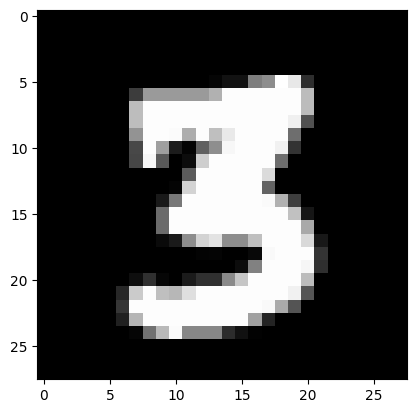

In [3]:
import numpy as np
import struct
import matplotlib.pyplot as plt

# --- 1. DATA LOADING LOGIC ---
# MNIST files are stored in a special binary format (IDX). 
# We use 'struct' to unpack the bytes into numbers.
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        # Read the header: magic number, number of images, rows, cols
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows * cols)
        # Normalize to 0-1 and transpose: (features, samples)
        return images.T / 255.0

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        # Read header: magic number, number of items
        magic, num = struct.unpack(">II", f.read(8))
        return np.fromfile(f, dtype=np.uint8)

# --- 2. THE NEURAL NETWORK MATH ---
def init_params():
    # Layer 1: 10 neurons, Layer 2 (Output): 10 neurons
    W1 = np.random.randn(10, 784) * 0.01
    b1 = np.zeros((10, 1))
    W2 = np.random.randn(10, 10) * 0.01
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    # Shift Z by max(Z) to avoid numerical overflow (exp of large numbers)
    exp = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp / np.sum(exp, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    oh = np.zeros((Y.size, 10))
    oh[np.arange(Y.size), Y] = 1
    return oh.T

# --- 3. BACKPROPAGATION ---
# This is the "Learning" engine. We find how much we missed (error) 
# and distribute that error back to the weights.
def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    OH_Y = one_hot(Y)
    
    # Layer 2 Error
    dZ2 = A2 - OH_Y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    
    # Layer 1 Error (Backpropagating through ReLU)
    dZ1 = W2.T.dot(dZ2) * (Z1 > 0)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

# --- 4. EXECUTION ---
if __name__ == "__main__":
    # Load data (Assuming files are in the same directory)
    print("Loading data...")
    X_train = load_mnist_images('train-images.idx3-ubyte')
    Y_train = load_mnist_labels('train-labels.idx1-ubyte')
    X_test = load_mnist_images('t10k-images.idx3-ubyte')
    Y_test = load_mnist_labels('t10k-labels.idx1-ubyte')

    # Initialize and Train
    W1, b1, W2, b2 = init_params()
    epochs = 500
    learning_rate = 0.2

    print("Training started...")
    for i in range(epochs + 1):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_train)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X_train, Y_train)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        if i % 50 == 0:
            predictions = np.argmax(A2, 0)
            accuracy = np.sum(predictions == Y_train) / Y_train.size
            print(f"Iteration {i:3} | Accuracy: {accuracy:.4f}")

    # Final visual test on one random image
    idx = np.random.randint(0, 10000)
    sample = X_test[:, idx, None]
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, sample)
    
    print(f"\nFinal Test - Predicted: {np.argmax(A2)}, Actual: {Y_test[idx]}")
    plt.imshow(sample.reshape(28, 28), cmap='gray')
    plt.show()